In [16]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

import os # 파일 시스템 경로 작업을 위해 (CSV 파일 로드 시 유용)

# 데이터 분할 및 모델 선택 도구
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score,cross_validate

# 전처리 도구
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 머신러닝 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 모델 평가 지표
from sklearn.metrics import classification_report, accuracy_score, \
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, \
        r2_score

# 단순 선형회귀 모델 만들기

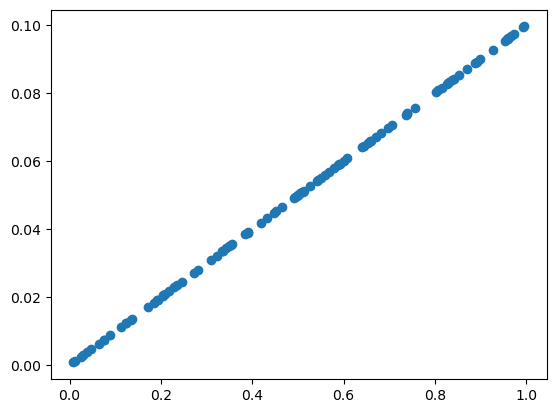

In [4]:
x = np.random.rand(100)
y = 0.2 * x * 0.5  # ax+b

plt.scatter(x,y)

In [5]:
def plt_prediction(pred, y):
    plt.figure(figsize=(8,6))
    plt.scatter(x, y, color='blue', label='Actual')
    plt.scatter(x, pred, color='orange', label='Prediction')
    plt.legend()
    plt.show()

In [6]:
# 경사하강법  y=xw+b, w 결정
w = np.random.uniform(-1,1)
b = np.random.uniform(-1,1)
learning_rate = 0.5 # 임의 값

Epoch 0, w : 0.0218, Error : 0.3691 


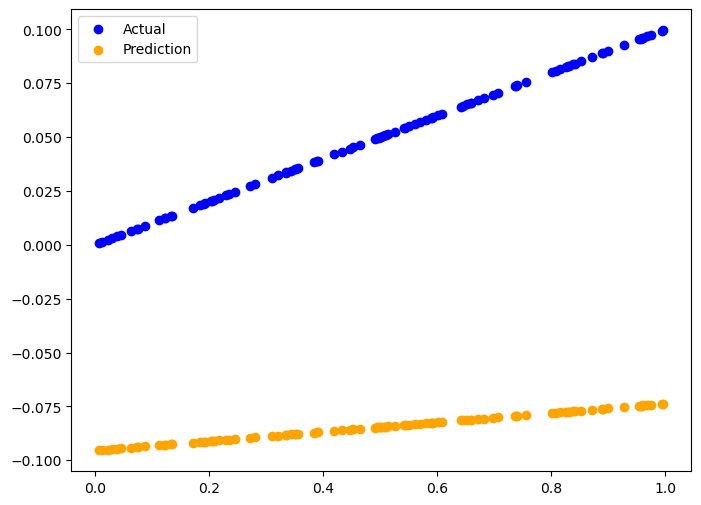

Epoch 10, w : 0.0848, Error : 0.0038 


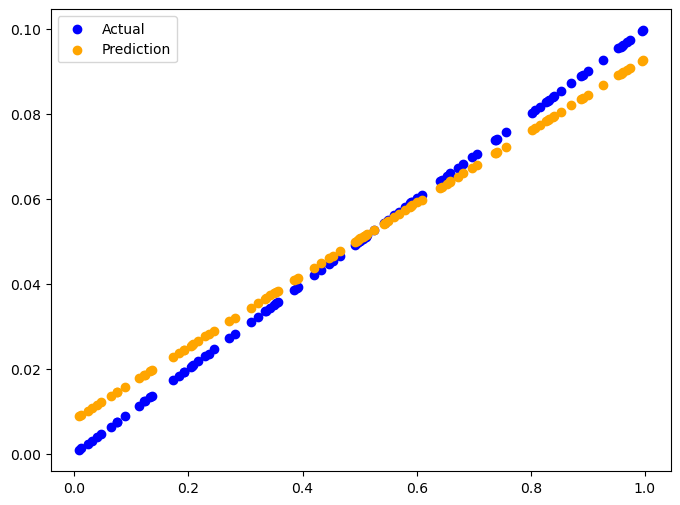

Epoch 20, w : 0.0891, Error : 0.0027 


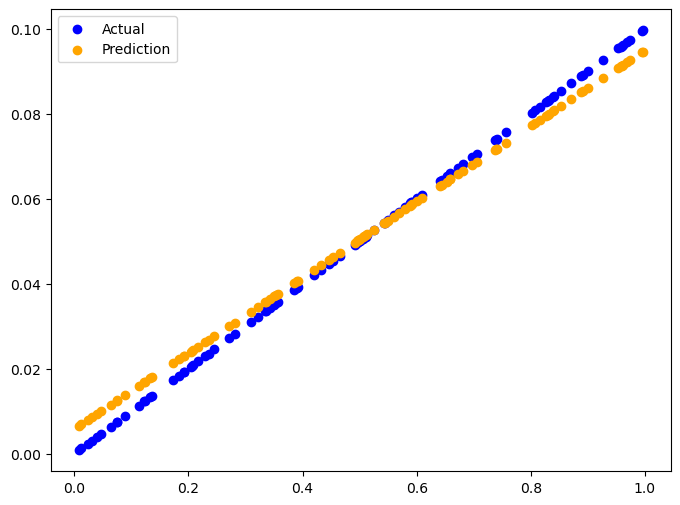

Epoch 30, w : 0.0921, Error : 0.0020 


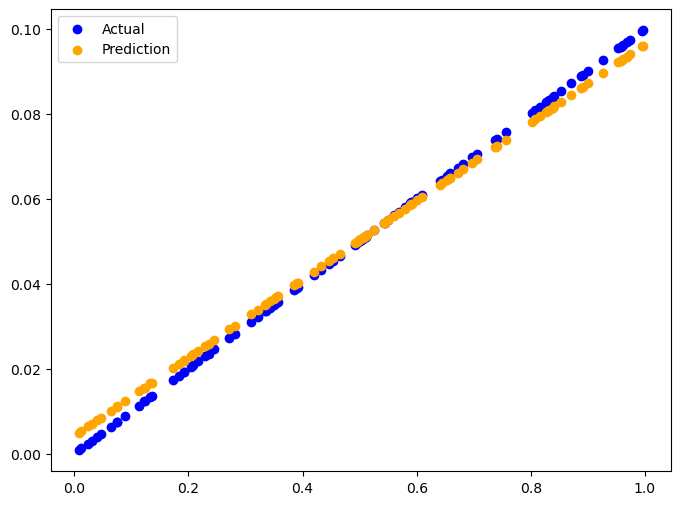

Epoch 40, w : 0.0943, Error : 0.0014 


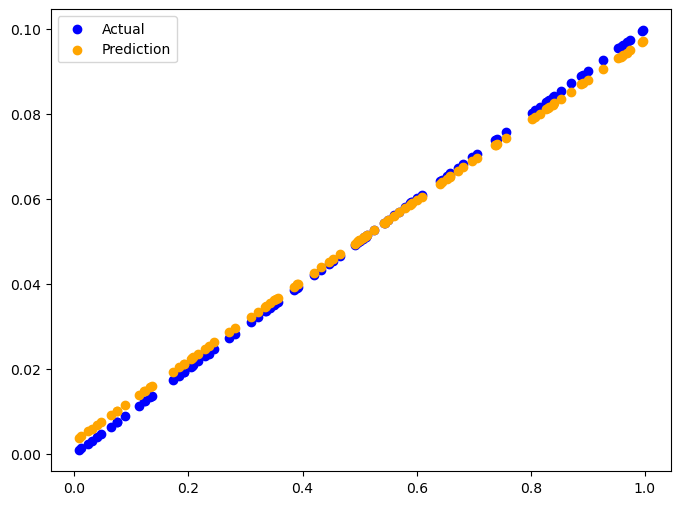

Epoch 50, w : 0.0959, Error : 0.0010 


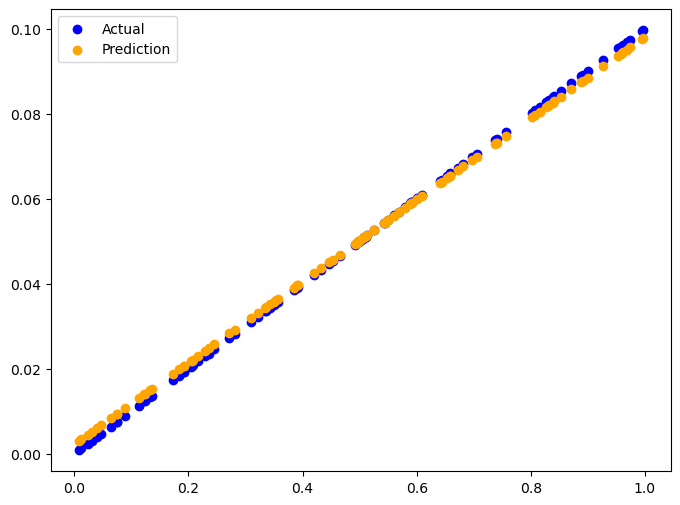

In [7]:
for epoch in range (100):
    y_pred = w * x + b
    error = np.abs(y_pred - y).mean()
    if error < 0.001 :
        break
    w_descent = learning_rate * ( (y_pred - y)* x).mean()
    b_descent = learning_rate * ( (y_pred - y).mean())
    w = w - w_descent
    b = b - b_descent
    
    if epoch%10 == 0:
        print(f'Epoch {epoch}, w : {w:.4f}, Error : {error:.4f} ')
        y_pred =  w * x + b
        plt_prediction(y_pred, y)

In [8]:
bostondf = pd.read_csv('./data/boston.csv')
bostondf.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7


In [9]:
X = bostondf.drop('target', axis = 1).values
y = bostondf['target'].values
bostondf.shape

(506, 14)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                 y, 
                 test_size= 0.3, 
                 random_state= 156)
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
y_pred[:3]

array([23.15424087, 19.65590246, 36.42005168])

In [11]:
# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse, mse

(np.float64(4.158956107955705), np.float64(17.296915907902065))

In [12]:
# 결정계수
r2_score(y_test, y_pred)

np.float64(0.7572263323138934)

In [13]:
#  회귀식
# w1, w0
lr.intercept_, lr.coef_

(np.float64(40.99559517216439),
 array([-1.12979614e-01,  6.55124002e-02,  3.44366694e-02,  3.04589777e+00,
        -1.97958320e+01,  3.35496880e+00,  5.93713290e-03, -1.74185354e+00,
         3.55884364e-01, -1.42954516e-02, -9.20180066e-01,  1.03966156e-02,
        -5.66182106e-01]))

y = w0 + w1*x1 + .... + w13*x13

In [14]:
np.round(lr.intercept_, 1), np.round(lr.coef_, 1)

(np.float64(41.0),
 array([ -0.1,   0.1,   0. ,   3. , -19.8,   3.4,   0. ,  -1.7,   0.4,
         -0. ,  -0.9,   0. ,  -0.6]))

In [15]:
pd.Series(data = np.round(lr.coef_, 1), 
          index=bostondf.drop('target', axis=1).columns).sort_values(ascending=False)

RM          3.4
CHAS        3.0
RAD         0.4
ZN          0.1
INDUS       0.0
B           0.0
TAX        -0.0
AGE         0.0
CRIM       -0.1
LSTAT      -0.6
PTRATIO    -0.9
DIS        -1.7
NOX       -19.8
dtype: float64

In [19]:
neg_mse_scores=cross_val_score(lr, X, y, scoring='neg_mean_squared_error', cv = 5)
neg_mse_scores

array([-12.46030057, -26.04862111, -33.07413798, -80.76237112,
       -33.31360656])

In [21]:
# mse, rmse, r2
rmse = np.sqrt(neg_mse_scores*-1)
np.mean(rmse),rmse

(np.float64(5.828658946215813),
 array([3.52991509, 5.10378498, 5.75101191, 8.9867887 , 5.77179405]))

In [23]:
# r2 
r2_scores=cross_val_score(lr, X, y, scoring='r2', cv = 5)
np.mean(r2_scores), r2_scores

(np.float64(0.3532759243958839),
 array([ 0.63919994,  0.71386698,  0.58702344,  0.07923081, -0.25294154]))

오차가 커지고 (4.15 > 5.82), 결정계수는 작아진 결과